In [1]:
import pathlib
import matplotlib.pyplot as plt
import PIL
#numpy / pandas / os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file 
#train_test_split
from sklearn.model_selection import  train_test_split
import shutil
#tensorflow + keras 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
from pathlib import Path
input_folder = Path('../input/v2-plant-seedlings-dataset')
output_folder = './dataset'

In [3]:
!pip install split-folders

  Obtaining dependency information for split-folders from https://files.pythonhosted.org/packages/df/74/ef5fdf217c770376a68bea21d0363e0af5759e0d2755886b0d17256ce8cf/split_folders-0.6.1-py3-none-any.whl.metadata


In [4]:
import splitfolders 
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.8, .0, .2)) 

Copying files: 5539 files [00:41, 132.28 files/s]


In [5]:
import os

def print_folder_structure(root_folder, excluded_extensions=('png',)):
    for root, dirs, files in os.walk(root_folder):
        level = root.replace(root_folder, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print('{}{}/'.format(indent, os.path.basename(root)))
        subindent = ' ' * 4 * (level + 1)
        for file in files:
            if not any(file.lower().endswith(ext) for ext in excluded_extensions):
                print('{}{}'.format(subindent, file))

root_folder = '/kaggle/working/'
excluded_extensions = ('png',)
print_folder_structure(root_folder, excluded_extensions)

/
.virtual_documents/
    __notebook_source__.ipynb
dataset/
    train/
        Small-flowered Cranesbill/
        Scentless Mayweed/
        Maize/
        Shepherd’s Purse/
        Common Chickweed/
        Charlock/
        Common wheat/
        Black-grass/
        Sugar beet/
        Cleavers/
        Fat Hen/
        nonsegmentedv2/
        Loose Silky-bent/
    test/
        Small-flowered Cranesbill/
        Scentless Mayweed/
        Maize/
        Shepherd’s Purse/
        Common Chickweed/
        Charlock/
        Common wheat/
        Black-grass/
        Sugar beet/
        Cleavers/
        Fat Hen/
        nonsegmentedv2/
        Loose Silky-bent/
    val/
        Small-flowered Cranesbill/
        Scentless Mayweed/
        Maize/
        Shepherd’s Purse/
        Common Chickweed/
        Charlock/
        Common wheat/
        Black-grass/
        Sugar beet/
        Cleavers/
        Fat Hen/
        nonsegmentedv2/
        Loose Silky-bent/


In [6]:
import glob

def print_dataset_lengths(train_length, test_length):
    print(f"Train Length: {train_length}")
    print(f"Test Length: {test_length}")

# the paths to train and test folders
train_folder = '/kaggle/working/dataset/train'
test_folder = '/kaggle/working/dataset/test'

# Calculate the lengths of train and test datasets
train_length = sum(len(glob.glob(f'{train_folder}/*/*.png')) for name in glob.glob(train_folder))
test_length = sum(len(glob.glob(f'{test_folder}/*/*.png')) for name in glob.glob(test_folder))

# Print the lengths
print_dataset_lengths(train_length, test_length)

Train Length: 4426
Test Length: 1113


In [7]:
batch_size = 32
img_height = 120
img_width = 120

In [8]:
data_dir_train = '/kaggle/working/dataset/train'
data_dir_test = '/kaggle/working/dataset/test'

In [9]:
# creating train dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(data_dir_train, validation_split=0.2, subset='training', seed=123,
                                                               image_size=(img_height, img_width), batch_size=batch_size )


Found 4426 files belonging to 13 classes.
Using 3541 files for training.


In [10]:
# creating validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(data_dir_train, validation_split=0.2, subset="validation", seed=123,
                                                            image_size=(img_height, img_width), batch_size=batch_size)

Found 4426 files belonging to 13 classes.
Using 885 files for validation.


In [11]:
import os
import shutil

folders = ['train', 'test', 'val']

for folder in folders:
    folder_path = f'/kaggle/working/dataset/{folder}/nonsegmentedv2'

    if os.path.exists(folder_path):
        shutil.rmtree(folder_path)
        print(f"{folder_path} has been deleted.")
    else:
        print(f"{folder_path} does not exist.")

/kaggle/working/dataset/train/nonsegmentedv2 has been deleted.
/kaggle/working/dataset/test/nonsegmentedv2 has been deleted.
/kaggle/working/dataset/val/nonsegmentedv2 has been deleted.


In [12]:
## Data visualisation

In [13]:
# Listing out all the classes of plant seedlings and store them in a list.
labels = sorted(os.listdir(data_dir_train))
print(labels)


['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'Shepherd’s Purse', 'Small-flowered Cranesbill', 'Sugar beet']


In [14]:
# creating a list which counts the number of images in each class of plant seedling
count_plot = []
for i in labels:
    count_plot.append(len(os.listdir(os.path.join(data_dir_train,i))))

In [15]:
count_plot

[247, 361, 268, 570, 202, 430, 609, 205, 485, 219, 460, 370]

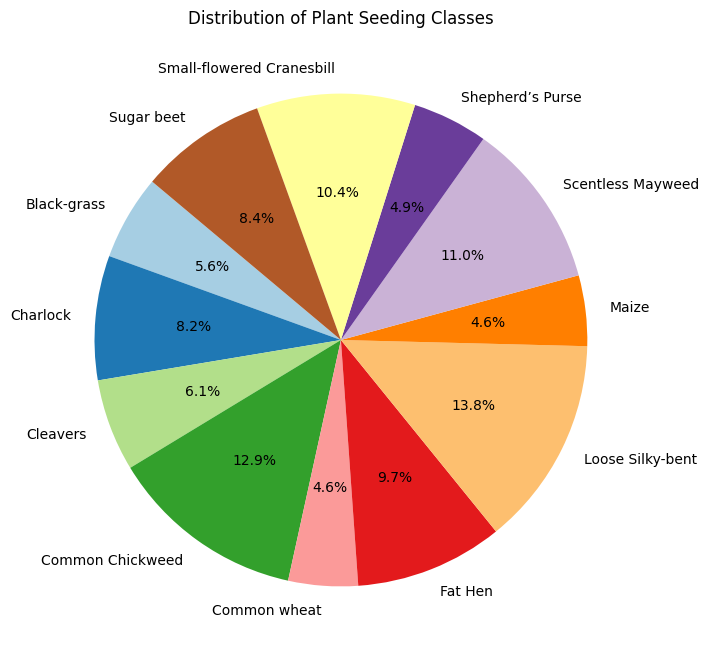

In [16]:
percentages = count_plot / np.sum(count_plot) * 100
# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(percentages, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Distribution of Plant Seeding Classes')
plt.show()

### Model : 

### Data Augmentation : 

In [17]:
image_dir = Path('../input/v2-plant-seedlings-dataset')

# Get filepaths and labels
filepaths = list(image_dir.glob(r'**/*.png'))
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

In [18]:
filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

# Concatenating filepaths and labels
image_df = pd.concat([filepaths, labels], axis=1)

# Shuffling the DataFrame and reset index
image_df = image_df.sample(frac=1).reset_index(drop = True)

# result
image_df.head(3)

,Filepath,Label
0,../input/v2-plant-seedlings-dataset/nonsegment...,Scentless Mayweed
1,../input/v2-plant-seedlings-dataset/Charlock/6...,Charlock
2,../input/v2-plant-seedlings-dataset/nonsegment...,Scentless Mayweed


In [19]:
def create_gen():
    # Load the Images with a generator and Data Augmentation
    train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
        validation_split=0.1
    )

    test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
    )

    train_images = train_generator.flow_from_dataframe(
        dataframe=train_df,
        x_col='Filepath',
        y_col='Label',
        target_size=(224, 224),
        color_mode='rgb',
        class_mode='categorical',
        batch_size=32,
        shuffle=True,
        seed=0,
        subset='training',
        rotation_range=30, # Uncomment to use data augmentation
        zoom_range=0.15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.15,
        horizontal_flip=True,
        fill_mode="nearest"
    )

    val_images = train_generator.flow_from_dataframe(
        dataframe=train_df,
        x_col='Filepath',
        y_col='Label',
        target_size=(224, 224),
        color_mode='rgb',
        class_mode='categorical',
        batch_size=32,
        shuffle=True,
        seed=0,
        subset='validation',
        rotation_range=30, # Uncomment to use data augmentation
        zoom_range=0.15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.15,
        horizontal_flip=True,
        fill_mode="nearest"
    )

    test_images = test_generator.flow_from_dataframe(
        dataframe=test_df,
        x_col='Filepath',
        y_col='Label',
        target_size=(224, 224),
        color_mode='rgb',
        class_mode='categorical',
        batch_size=32,
        shuffle=False
    )
    
    return train_generator,test_generator,train_images,val_images,test_images

In [20]:
# Load the pretained model MobileNet 
pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

pretrained_model.trainable = False

9406464/9406464 [==============================] - 1s 0us/step


In [21]:
# Separate in train and test data
train_df, test_df = train_test_split(image_df, train_size=0.9, shuffle=True, random_state=1)

# Create the generators
train_generator,test_generator,train_images,val_images,test_images = create_gen()

Found 8973 validated image filenames belonging to 12 classes.
Found 997 validated image filenames belonging to 12 classes.
Found 1108 validated image filenames belonging to 12 classes.


In [22]:
inputs = pretrained_model.input

x = tf.keras.layers.Dense(128, activation='relu')(pretrained_model.output)
x = tf.keras.layers.Dense(128, activation='relu')(x)

outputs = tf.keras.layers.Dense(12, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_images,
    validation_data=val_images,
    batch_size = 32,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=2,
            restore_best_weights=True
        )
    ]
)

Epoch 1/10
281/281 [==============================] - 105s 356ms/step - loss: 0.8212 - accuracy: 0.7190 - val_loss: 0.4910 - val_accuracy: 0.8245
Epoch 2/10
281/281 [==============================] - 78s 276ms/step - loss: 0.3539 - accuracy: 0.8736 - val_loss: 0.3689 - val_accuracy: 0.8686
Epoch 3/10
281/281 [==============================] - 76s 269ms/step - loss: 0.2282 - accuracy: 0.9201 - val_loss: 0.2647 - val_accuracy: 0.9007
Epoch 4/10
281/281 [==============================] - 75s 268ms/step - loss: 0.1597 - accuracy: 0.9468 - val_loss: 0.2169 - val_accuracy: 0.9248
Epoch 5/10
281/281 [==============================] - 75s 268ms/step - loss: 0.1278 - accuracy: 0.9551 - val_loss: 0.2283 - val_accuracy: 0.9208
Epoch 6/10
281/281 [==============================] - 76s 269ms/step - loss: 0.0942 - accuracy: 0.9670 - val_loss: 0.1907 - val_accuracy: 0.9348
Epoch 7/10
281/281 [==============================] - 82s 290ms/step - loss: 0.0803 - accuracy: 0.9730 - val_loss: 0.2311 - val_a

In [23]:
# Save the model
model.save('/kaggle/working/plant-seedlings-model')

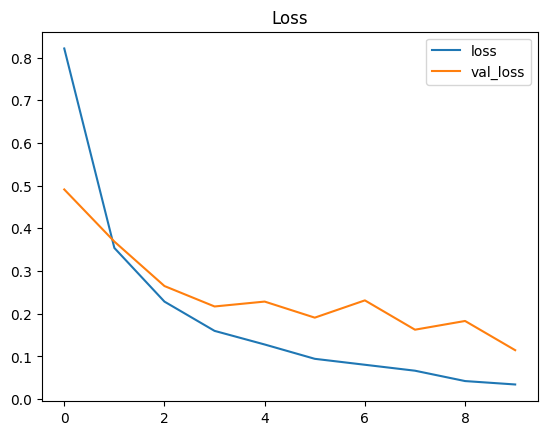

In [24]:
pd.DataFrame(history.history)[['loss','val_loss']].plot()
plt.title("Loss")
plt.show()

In [25]:
result = model.evaluate(test_images, verbose=0)

In [26]:
print("Test Loss: {:.5f}".format(result[0]))
print("Accuracy on the test set: {:.2f}%".format(result[1] * 100))

Test Loss: 0.14300
Accuracy on the test set: 96.30%


In [27]:
# Predict the label of the test_images
pred = model.predict(test_images)
pred = np.argmax(pred,axis=1)

# Map the label
lab = (train_images.class_indices)
lab = dict((v,k) for k,v in lab.items())
pred = [lab[k] for k in pred]

# Display the result
print(f'The first 5 predictions: {pred[:5]}')

35/35 [==============================] - 9s 227ms/step
The first 5 predictions: ['Sugar beet', 'Scentless Mayweed', 'Fat Hen', 'Common Chickweed', 'Fat Hen']


In [28]:
from sklearn.metrics import classification_report

# Assuming y_test is your true labels and pred is your predicted labels
y_test = list(test_df.Label)
report = classification_report(y_test, pred, zero_division=1)

print(report)

                           precision    recall  f1-score   support

              Black-grass       0.79      0.88      0.83        50
                 Charlock       1.00      0.99      0.99        74
                 Cleavers       1.00      1.00      1.00        76
         Common Chickweed       0.98      1.00      0.99       134
             Common wheat       0.92      1.00      0.96        49
                  Fat Hen       0.98      0.96      0.97       117
         Loose Silky-bent       0.97      0.91      0.94       170
                    Maize       0.96      0.96      0.96        46
        Scentless Mayweed       0.98      0.92      0.95       133
         Shepherd’s Purse       0.90      1.00      0.95        61
Small-flowered Cranesbill       0.98      1.00      0.99       114
               Sugar beet       0.98      0.99      0.98        84

                 accuracy                           0.96      1108
                macro avg       0.95      0.97      0.96    

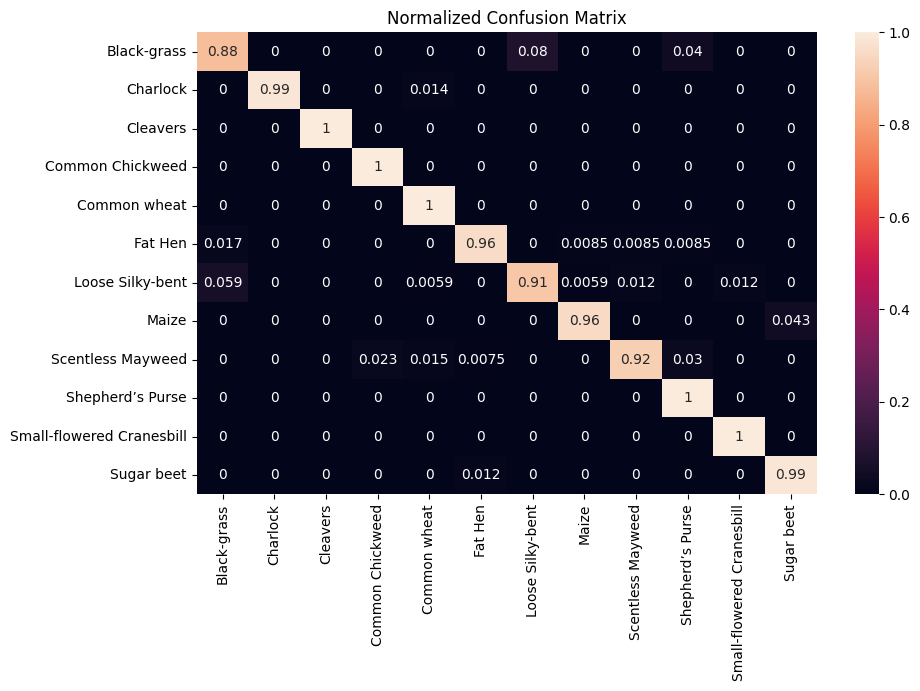

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cf_matrix = confusion_matrix(y_test, pred, normalize='true')
plt.figure(figsize = (10,6))
sns.heatmap(cf_matrix, annot=True, xticklabels = sorted(set(y_test)), yticklabels = sorted(set(y_test)))
plt.title('Normalized Confusion Matrix')
plt.show()

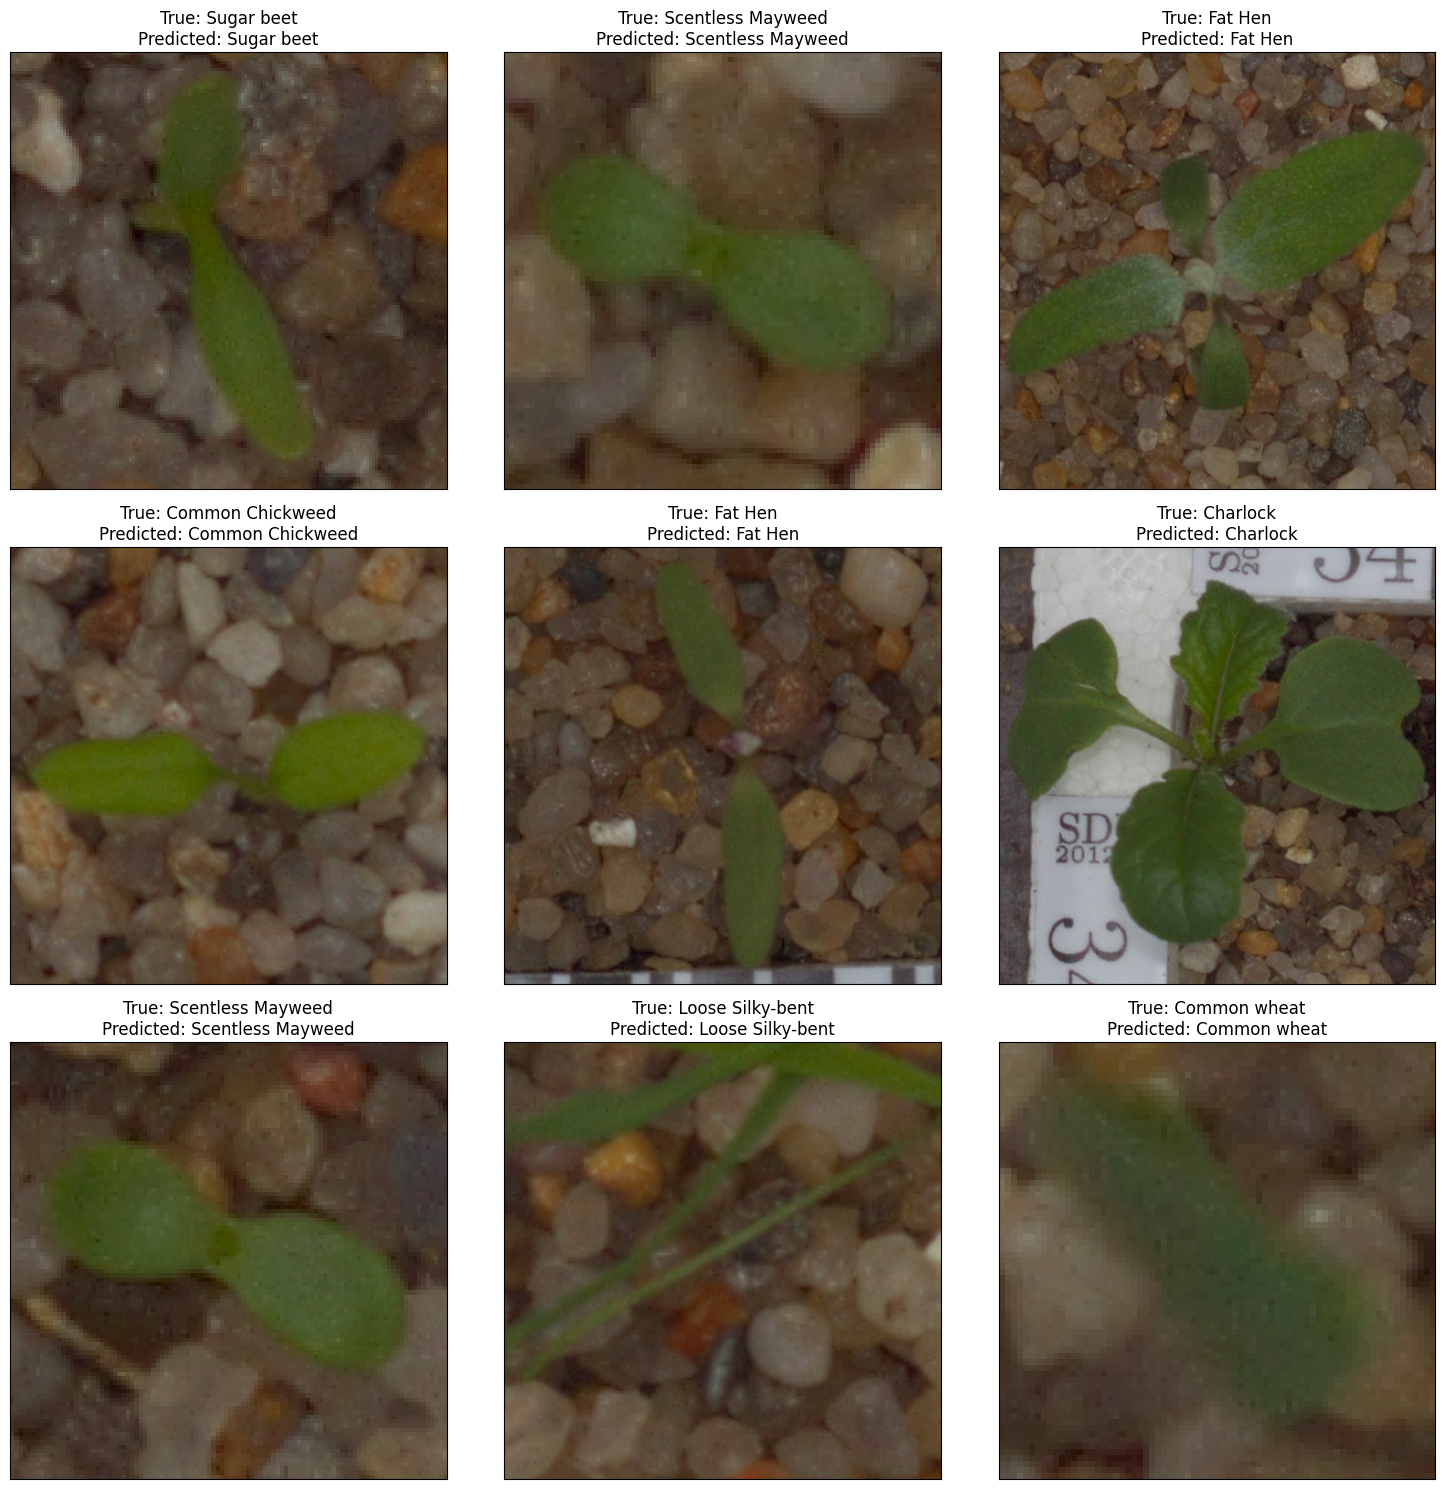

In [30]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(test_df.Filepath.iloc[i]))
    ax.set_title(f"True: {test_df.Label.iloc[i]}\nPredicted: {pred[i]}")
plt.tight_layout()
plt.show()